# Group 6 - Painting Classification

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import necessary libraries

In [2]:
# Need to install to detect duplicated images
!pip install imagededup
!pip install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.6/318.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.1 MB/s eta 0:00:00


In [3]:
# Import libraries

# Basic standard used libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Library to check image properties imports
import cv2
from collections import Counter
from PIL import Image
from tqdm import tqdm

# File path imports
import os
from pathlib import Path

# Python standard library imports
from typing import Any
from random import sample
from tqdm.notebook import tqdm

# Array manipulation imports
from numpy import ndarray

# Plot imports
from matplotlib.pyplot import subplots, show

# Image duplicator imports
from imagededup.methods import PHash
from imagededup.utils import plot_duplicates
import hashlib
import matplotlib.gridspec as gridspec
import imagehash

# Data split imports
from sklearn.model_selection import train_test_split
from collections import defaultdict
import shutil

# Generate dataset imports
import tensorflow as tf
import keras

# Data Augmentation imports
from keras import layers

# Model building imports
from keras import Model, Sequential, Input

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import LeakyReLU
from keras.ops import add
from keras.utils import to_categorical

# Model training imports
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, Precision, Recall, F1Score
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler, EarlyStopping

# Augmentation operations
from keras.layers import RandomBrightness, RandomFlip, RandomRotation
from keras.layers import Pipeline

# Variant set up
AUTOTUNE = tf.data.AUTOTUNE
SEED = 6666
SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

In [4]:
# Code from: https://www.geeksforgeeks.org/python/unzipping-files-in-python/
# Extract all files from the wikiart zip folder

# importing the zipfile module
from zipfile import ZipFile

# loading the temp.zip and creating a zip object

# When runned locally
#zip_path = os.path.join(".", 'wikiart.zip')
#with ZipFile(zip_path, "r") as zObject:

# When runned in Colab
with ZipFile("/content/drive/MyDrive/Project/wikiart.zip", 'r') as zObject:

    # Extracting all the members of the zip into a specific location.

    # When runned locally
    #zObject.extractall(path = os.path.join("."))

    # When runned in Colab
    zObject.extractall(path="/content/drive/MyDrive/Project")

## 2. Load & Explore data

### 2.1 Image properties

In [5]:
# Directory/folder path where the data is located

# When runned locally
#directory = os.path.join(".", 'wikiart')

# When runned in Colab
directory = '/content/drive/MyDrive/Project/wikiart'

# Subfolders/painters' names
painters = sorted([folder for folder in os.listdir(directory) if os.path.isdir(os.path.join(directory, folder))])

print(painters)

['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [6]:
wikiart_summary = {
    "total_files": 0,
    "corrupted_files": 0,
    "formats": Counter(),
    "modes": Counter(),
    "sizes": Counter(),
}

directory = Path(directory)
subdirs = [p for p in directory.iterdir() if p.is_dir()]
for painter_dir in tqdm(subdirs, desc="Scanning each painter's folder"):
  img_files = sorted(
      f for f in painter_dir.iterdir()
      if f.is_file() and f.suffix.lower() in SUPPORTED_EXTENSIONS
  )

  for img_path in img_files:
    wikiart_summary["total_files"] += 1       # Update the total of files

    try:
      with Image.open(img_path) as img:
        fmt = img.format or 'Not img'
        wikiart_summary["formats"][fmt] += 1  # Update the format count
        wikiart_summary["modes"][img.mode] += 1   # Update the mode (RGB) count
        wikiart_summary["sizes"][img.size] += 1   # Update the size count
    except OSError:
      wikiart_summary["corrupted_files"] += 1

print("\n")
print(f"Total number of files: {wikiart_summary['total_files']}")
print(f"Total number of corrupted files: {wikiart_summary['corrupted_files']}")
print(f"Formats: {wikiart_summary['formats']}")
print(f"Modes: {wikiart_summary['modes']}")
print(f"Sizes: {wikiart_summary['sizes']}")

Scanning each painter's folder:   0%|          | 0/23 [00:00<?, ?it/s]



Total number of files: 13340
Total number of corrupted files: 0
Formats: Counter({'JPEG': 13340})
Modes: Counter({'RGB': 13340})
Sizes: Counter({(512, 512): 13340})


### 2.2 Class Distribution

In [7]:
# Count number of files/paintings per folder/painter

# Total number of painting in the wikiart dataset
file_count = wikiart_summary["total_files"]  # 13340

# List with painting counts per painter
img_count = []

for painter in painters:
  path = os.path.join(directory, painter)

  img_count.append(len(os.listdir(path)))

  print(f"{painter}: {len(os.listdir(path))} files ({round((len(os.listdir(path))/file_count)*100, 1)}%)")

total_img = sum(img_count)
mean_img = np.mean(img_count)
median_img = np.median(img_count)
std_img = np.std(img_count)
min_img = min(img_count)
max_img = max(img_count)
imbalance_ratio = max_img / min_img

print("-------------------------------------------")
print(f"Number of painters/classes: {len(painters)}")
print(f"Total of paintings: {total_img}")
print(f"Mean paintings per painter: {mean_img:.1f}")
print(f"Median: {median_img:.1f}")
print(f"Standard deviation: {std_img:.1f}")
print(f"Minimum: {min_img} ({painters[img_count.index(min_img)]})")
print(f"Maximum: {max_img} ({painters[img_count.index(max_img)]})")
print(f"Imbalance ratio: {imbalance_ratio:.1f}")

Albrecht_Durer: 580 files (4.3%)
Boris_Kustodiev: 444 files (3.3%)
Camille_Pissarro: 621 files (4.7%)
Childe_Hassam: 385 files (2.9%)
Claude_Monet: 934 files (7.0%)
Edgar_Degas: 428 files (3.2%)
Eugene_Boudin: 389 files (2.9%)
Gustave_Dore: 528 files (4.0%)
Ilya_Repin: 378 files (2.8%)
Ivan_Aivazovsky: 404 files (3.0%)
Ivan_Shishkin: 364 files (2.7%)
John_Singer_Sargent: 549 files (4.1%)
Marc_Chagall: 536 files (4.0%)
Martiros_Saryan: 403 files (3.0%)
Nicholas_Roerich: 1274 files (9.6%)
Pablo_Picasso: 534 files (4.0%)
Paul_Cezanne: 406 files (3.0%)
Pierre_Auguste_Renoir: 975 files (7.3%)
Pyotr_Konchalovsky: 644 files (4.8%)
Raphael_Kirchner: 362 files (2.7%)
Rembrandt: 544 files (4.1%)
Salvador_Dali: 336 files (2.5%)
Vincent_van_Gogh: 1322 files (9.9%)
-------------------------------------------
Number of painters/classes: 23
Total of paintings: 13340
Mean paintings per painter: 580.0
Median: 528.0
Standard deviation: 274.4
Minimum: 336 (Salvador_Dali)
Maximum: 1322 (Vincent_van_Gogh)


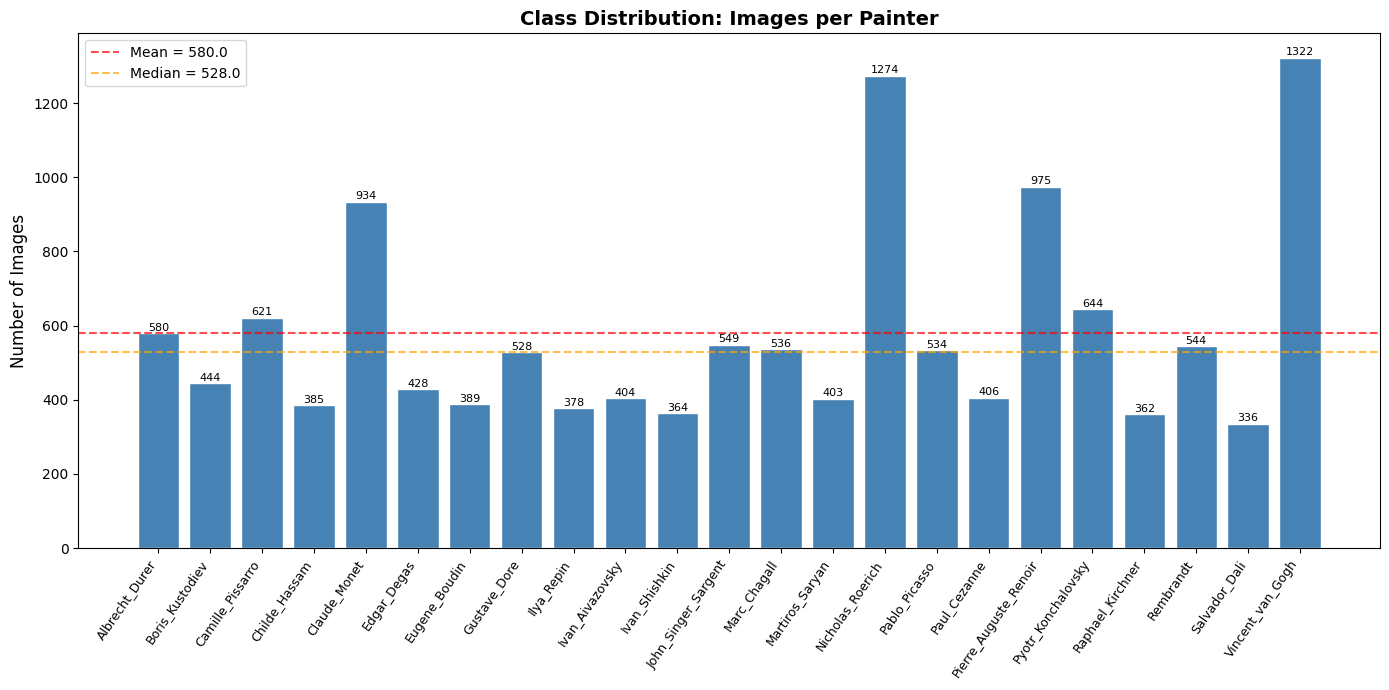

In [8]:
# Class distribution plot
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(painters)), img_count, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(painters)))
ax.set_xticklabels(painters, rotation=55, ha='right', fontsize=9)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution: Images per Painter', fontsize=14, fontweight='bold')
ax.axhline(y=mean_img, color='red', linestyle='--', alpha=0.7, label=f'Mean = {mean_img:.1f}')
ax.axhline(y=median_img, color='orange', linestyle='--', alpha=0.7, label=f'Median = {median_img:.1f}')
ax.legend(fontsize=10)

for bar, count in zip(bars, img_count):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

It seems that we have an imbalanced dataset. For example, Vincent Van Gogh has a total of 1,322 paintings (close to representing 10% of the dataset) while Salvador Dalí has only 336 paintings (2.5%) present in this dataset.

In summary:
- there are in total 13,340 files/paintings
- each image is having a size of 512 x 512
- each image is having a 'jpg' format
- the dataset is imbalanced

### 2.3 Duplicated images

Two methods:
- MD5 hash: detects exact (byte-for-byte) duplicates
- Perceptual hash (pHash): detects near-duplicates (augmented, resized, cropped, etc.), done within each painter.

In [9]:
# List of dicts with image metadata
data = []

for painter_dir in tqdm(subdirs, desc="Scanning painters"):
    painter_name = painter_dir.name
    image_files = sorted([
        f for f in painter_dir.iterdir()
        if f.suffix.lower() in SUPPORTED_EXTENSIONS
    ])

    for img_path in image_files:
        entry = {
            'painter': painter_name,
            'filename': img_path.name,
            'filepath': str(img_path),
            'filesize_kb': img_path.stat().st_size / 1024,
        }

        with Image.open(img_path) as img:
            entry['width'] = img.width
            entry['height'] = img.height
            entry['mode'] = img.mode
            entry['format'] = img.format
            entry['aspect_ratio'] = round(img.width / img.height, 3)

        data.append(entry)

Scanning painters:   0%|          | 0/23 [00:00<?, ?it/s]

In [10]:
# Group images by painter
by_painter = defaultdict(list)
for entry in data:
    by_painter[entry['painter']].append(entry)

# MD5 exact duplicates
print("Computing MD5 hashes (exact duplicates)...")
md5_map = defaultdict(list)
for entry in tqdm(data, desc="MD5 hashing"):
        h = hashlib.md5(open(entry['filepath'], 'rb').read()).hexdigest()
        md5_map[h].append(entry['filepath'])

exact_duplicates = {h: paths for h, paths in md5_map.items() if len(paths) > 1}
print(f"\nExact duplicates: {len(exact_duplicates)} groups, "
      f"{sum(len(v) for v in exact_duplicates.values())} images total")

for h, paths in list(exact_duplicates.items()):
    print(f"  MD5: {h}")
    for p in paths:
        print(f"    {p}")

Computing MD5 hashes (exact duplicates)...


MD5 hashing:   0%|          | 0/13340 [00:00<?, ?it/s]


Exact duplicates: 2 groups, 4 images total
  MD5: 9ff6d522bb091d88c59b50625904226a
    /content/drive/MyDrive/Project/wikiart/Childe_Hassam/childe-hassam_the-norwegian-cottage-1.jpg
    /content/drive/MyDrive/Project/wikiart/Childe_Hassam/childe-hassam_the-norwegian-cottage.jpg
  MD5: 23d48b2c540d091f586174c4f8d07773
    /content/drive/MyDrive/Project/wikiart/Childe_Hassam/childe-hassam_view-of-florence-from-san-miniato-1.jpg
    /content/drive/MyDrive/Project/wikiart/Childe_Hassam/childe-hassam_view-of-florence-from-san-miniato.jpg


In [11]:
# Perceptual hash near-duplicates
near_duplicates = []

print("Computing perceptual hashes (near-duplicates, within each painter)...")

painter_hashes = {}
for painter, entries in tqdm(by_painter.items(), desc="pHash by painter"):
    hashes = []
    for entry in entries:
        try:
            with Image.open(entry['filepath']) as img:
                ph = imagehash.phash(img, hash_size=16)
                hashes.append((entry['filepath'], ph))
        except Exception:
            pass
    painter_hashes[painter] = hashes

print("\nComparing hashes within each painter...")
for painter, hashes in tqdm(painter_hashes.items(), desc="Comparing"):
    n = len(hashes)
    for i in range(n):
        for j in range(i + 1, n):
            dist = hashes[i][1] - hashes[j][1]
            if dist <= 100:
                near_duplicates.append((
                    hashes[i][0],
                    hashes[j][0],
                    int(dist),
                    painter
                ))

near_duplicates.sort(key=lambda x: x[2])
print(f"\nNear-duplicate pairs found (pHash threshold ≤ {100}): {len(near_duplicates)}")

if near_duplicates:
    dist_dist = Counter(d[2] for d in near_duplicates)
    print(f"Distance distribution: {dict(sorted(dist_dist.items()))}")

Computing perceptual hashes (near-duplicates, within each painter)...


pHash by painter:   0%|          | 0/23 [00:00<?, ?it/s]


Comparing hashes within each painter...


Comparing:   0%|          | 0/23 [00:00<?, ?it/s]


Near-duplicate pairs found (pHash threshold ≤ 100): 4753
Distance distribution: {0: 2, 2: 3, 4: 2, 6: 2, 10: 1, 12: 4, 14: 5, 16: 3, 18: 2, 20: 4, 22: 6, 24: 4, 26: 10, 28: 8, 30: 10, 32: 6, 34: 11, 36: 9, 38: 6, 40: 5, 42: 2, 44: 7, 46: 5, 48: 1, 50: 6, 52: 7, 54: 3, 56: 3, 58: 5, 60: 9, 62: 6, 64: 6, 66: 6, 68: 2, 70: 9, 72: 7, 74: 7, 76: 8, 78: 5, 80: 15, 82: 12, 84: 22, 86: 28, 88: 42, 90: 82, 92: 102, 94: 266, 96: 550, 98: 1091, 100: 2336}


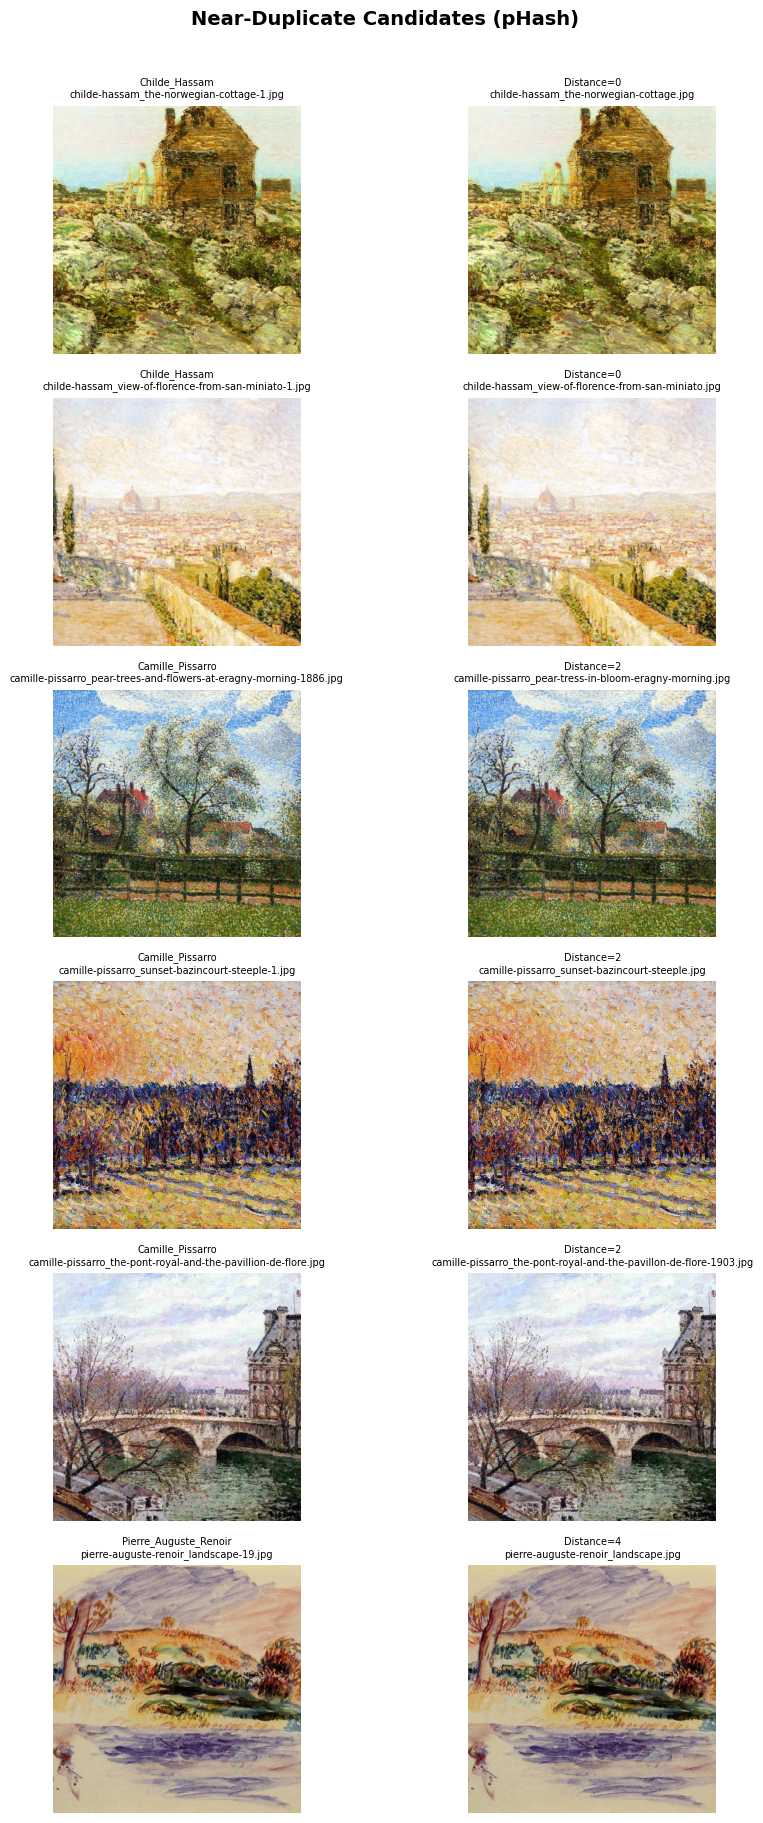

In [12]:
# Visualize near-duplicate examples
n_examples = min(6, len(near_duplicates))
fig, axes = plt.subplots(n_examples, 2, figsize=(10, 3 * n_examples))
if n_examples == 1:
    axes = [axes]

fig.suptitle('Near-Duplicate Candidates (pHash)', fontsize=14, fontweight='bold', y=1.01)

for idx in range(n_examples):
    img1_path, img2_path, dist, painter = near_duplicates[idx]
    try:
        img1 = Image.open(img1_path)
        img2 = Image.open(img2_path)
        axes[idx][0].imshow(img1)
        axes[idx][0].set_title(f'{painter}\n{Path(img1_path).name}', fontsize=7)
        axes[idx][0].axis('off')
        axes[idx][1].imshow(img2)
        axes[idx][1].set_title(f'Distance={dist}\n{Path(img2_path).name}', fontsize=7)
        axes[idx][1].axis('off')
    except Exception:
        pass

plt.tight_layout()
plt.show()

In [13]:
# Visual inspetion of pHash pairs by distance (0-80 range)

pairs_in_range = [p for p in near_duplicates if 0 <= p[2] <= 80]
pairs_by_distance = defaultdict(list)
for p in pairs_in_range:
    pairs_by_distance[p[2]].append(p)

print(f"Pairs in distance range [{0}, {80}]: {len(pairs_in_range)}")
print(f"Distances present: {sorted(pairs_by_distance.keys())}\n")

for dist in sorted(pairs_by_distance.keys()):
    pairs = pairs_by_distance[dist]
    n_pairs = len(pairs)

    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 3.5 * n_pairs))
    if n_pairs == 1:
        axes = [axes]

    fig.suptitle(f'pHash Distance = {dist}  ({n_pairs} pairs)',
                 fontsize=14, fontweight='bold', y=1.01)

    for idx, (img1_path, img2_path, d, painter) in enumerate(pairs):
        try:
            img1 = Image.open(img1_path)
            img2 = Image.open(img2_path)
            axes[idx][0].imshow(img1)
            axes[idx][0].set_title(f'{painter}\n{Path(img1_path).name}', fontsize=7)
            axes[idx][0].axis('off')
            axes[idx][1].imshow(img2)
            axes[idx][1].set_title(f'{painter}\n{Path(img2_path).name}', fontsize=7)
            axes[idx][1].axis('off')
        except Exception:
            pass

    plt.tight_layout()
    plt.show()
    print(f"{'─' * 80}\n")

Output hidden; open in https://colab.research.google.com to view.

We chose to assume the following:
- Images with distance <50 are equal
- Images with distance between 50 and 80 were analysed individually
- Images with distance >80 are different

In [14]:
# Pairs at distances 52-80 confirmed as the SAME artwork through visual inspection.
# Each entry is (filename_1, filename_2).
same_artwork_pairs = [
    # Distance 52 (6 of 7 pairs)
    ("albrecht-durer_man-of-sorrow-1522.jpg", "albrecht-durer_self-portrait-as-the-man-of-sorrows-1522.jpg"),
    ("camille-pissarro_the-diligence-1877.jpg", "camille-pissarro_the-stage-on-the-road-from-ennery-to-l-hermigate-pontoise.jpg"),
    ("rembrandt_man-in-a-golden-helmet-1669.jpg", "rembrandt_portrait-of-a-man-with-a-golden-helmet-1648.jpg"),
    ("vincent-van-gogh_bench-in-a-wood-1882(1).jpg", "vincent-van-gogh_the-bench-1882.jpg"),
    ("vincent-van-gogh_rooftops-1882.jpg", "vincent-van-gogh_view-from-the-window-of-vincent-s-studio-in-winter-1883-1.jpg"),
    ("vincent-van-gogh_vase-with-flieder-margerites-und-anemones-1887.jpg", "vincent-van-gogh_vase-with-lilacs-daisies-and-anemones-1887.jpg"),

    # Distance 54 (3 of 3 pairs)
    ("edgar-degas_after-the-bath-4.jpg", "edgar-degas_leaving-the-bath-1885.jpg"),
    ("pierre-auguste-renoir_bather-2.jpg", "pierre-auguste-renoir_bather-with-long-hair.jpg"),
    ("pierre-auguste-renoir_on-the-banks-of-the-river-1895.jpg", "pierre-auguste-renoir_on-the-river-banks-1907.jpg"),

    # Distance 56 (3 of 3 pairs)
    ("claude-monet_the-village-of-la-coche-blond-evening.jpg", "claude-monet_the-village-of-la-roche-blond-sunset.jpg"),
    ("edgar-degas_a-ballet-seen-from-the-opera-box-1885.jpg", "edgar-degas_ballerina-and-lady-with-a-fan-1885.jpg"),
    ("marc-chagall_abraham-is-going-to-sacrifice-his-son-1931.jpg", "marc-chagall_abraham-is-going-to-sacrifice-his-son-according-to-the-order-of-god-genesis-xxii-9-14.jpg"),

    # Distance 58 (5 of 5 pairs)
    ("albrecht-durer_conversion-of-paul.jpg", "albrecht-durer_the-conversion-of-st-paul-1495.jpg"),
    ("nicholas-roerich_a-steep-snow-slope-1924.jpg", "nicholas-roerich_pass-suget-1936.jpg"),
    ("nicholas-roerich_om-mani-padme-hum-1932.jpg", "nicholas-roerich_tibet-1937.jpg"),
    ("nicholas-roerich_young-men-successors-1914-2.jpg", "nicholas-roerich_young-men-successors-1914.jpg"),
    ("pierre-auguste-renoir_seated-bather-1912.jpg", "pierre-auguste-renoir_woman-sleeping.jpg"),

    # Distance 60 (6 of 9 pairs)
    ("claude-monet_floating-ice-on-the-seine-02.jpg", "claude-monet_the-ice-floes.jpg"),
    ("claude-monet_sun-setting-over-the-seine-at-lavacourt-winter-effect-1880.jpg", "claude-monet_sunset-on-the-seine-at-lavacourt-winter-effect.jpg"),
    ("gustave-dore_conversion-of-saul.jpg", "gustave-dore_the-conversion-of-st-paul-1866.jpg"),
    ("rembrandt_hendrickje-stoffels-in-velvet-beret.jpg", "rembrandt_portrait-of-hendrikje-stoffels-1654.jpg"),
    ("rembrandt_mater-dolorosa-1660.jpg", "rembrandt_the-virgin-of-sorrow-1661.jpg"),
    ("rembrandt_rembrandt-s-wife-dying-1642.jpg", "rembrandt_sick-woman-with-a-large-white-headdress-saskia.jpg"),

    # Distance 62 (3 of 6 pairs)
    ("rembrandt_a-beggar-sitting-in-an-elbow-chair-1630.jpg", "rembrandt_old-man-in-a-long-cloak-sitting-in-an-armchair-1630.jpg"),
    ("rembrandt_abraham-caressing-isaac-1636.jpg", "rembrandt_jacob-caressing-benjamin-1637.jpg"),
    ("rembrandt_circumcision.jpg", "rembrandt_simon-with-jesus-1669.jpg"),

    # Distance 64 (6 of 6 pairs)
    ("albrecht-durer_adoration-of-the-magi-1.jpg", "albrecht-durer_the-adoration-of-the-wise-men-1524.jpg"),
    ("claude-monet_the-basin-at-argenteuil.jpg", "claude-monet_the-marina-at-argenteuil-1872.jpg"),
    ("rembrandt_an-old-man-resting-his-hands-upon-a-book-1645.jpg", "rembrandt_old-man-in-meditation-leaning-on-a-book-1645.jpg"),
    ("rembrandt_pharisees-in-the-temple-jews-in-the-synagogue-1648.jpg", "rembrandt_the-synagogue-1648.jpg"),
    ("vincent-van-gogh_dunes-with-figures-1882(1).jpg", "vincent-van-gogh_dunes-with-figures-1882-1(1).jpg"),
    ("vincent-van-gogh_garden-with-weeping-willow-1888(1).jpg", "vincent-van-gogh_sunny-lawn-in-a-public-park-1888.jpg"),

    # Distance 66 (1 of 6 pairs)
    ("vincent-van-gogh_landscape-at-nuenen.jpg", "vincent-van-gogh_the-kingfisher-1884.jpg"),

    # Distance 68 (2 of 2 pairs)
    ("nicholas-roerich_study-of-scene-design-for-princess-maleine-1913.jpg", "nicholas-roerich_yard-of-castle-1913.jpg"),
    ("rembrandt_joris-de-caullery-1632.jpg", "rembrandt_portrait-of-joris-de-caullery-1632.jpg"),

    # -- Distance 70 (6 of 9 pairs) --
    ("gustave-dore_don-quixote-150.jpg", "gustave-dore_don-quixote-33.jpg"),
    ("nicholas-roerich_cloud-1913.jpg", "nicholas-roerich_untitled-1913.jpg"),
    ("nicholas-roerich_girls.jpg", "nicholas-roerich_two-girls-1930.jpg"),
    ("nicholas-roerich_sacred-himalayas-1934-1.jpg", "nicholas-roerich_sacred-himalayas-1934-2.jpg"),
    ("rembrandt_circumcision.jpg", "rembrandt_simeon-with-the-christ-child-in-the-temple.jpg"),
    ("vincent-van-gogh_seated-woman-4-1887.jpg", "vincent-van-gogh_sketch-of-a-seated-woman-1888.jpg"),

    # Distance 72 (4 of 7 pairs)
    ("camille-pissarro_jacob-coin-de-village.jpg", "camille-pissarro_village-corner-1863.jpg"),
    ("ivan-aivazovsky_seaside-city-view-of-yalta-1866.jpg", "ivan-aivazovsky_view-of-yalta-in-evening-1870.jpg"),
    ("nicholas-roerich_sacred-himalayas-1934-1.jpg", "nicholas-roerich_sacred-himalayas-1934.jpg"),
    ("pierre-auguste-renoir_roses-before-the-blue-curtain.jpg", "pierre-auguste-renoir_roses-in-front-of-a-blue-curtain-1908.jpg"),

    # Distance 74 (3 of 7 pairs)
    ("paul-cezanne_gustave-boyer-in-a-straw-hat.jpg", "paul-cezanne_man-in-a-straw-hat-1871.jpg"),
    ("paul-cezanne_head-of-an-old-man.jpg", "paul-cezanne_portrait-of-an-old-man.jpg"),
    ("rembrandt_peasant-family-on-the-tramp-1652.jpg", "rembrandt_three-peasants-travelling-1652.jpg"),

    # Distance 76 (2 of 8 pairs)
    ("gustave-dore_paolo-and-francesca-ii.jpg", "gustave-dore_the-inferno-canto-5.jpg"),
    ("rembrandt_mater-dolorosa-1660.jpg", "rembrandt_portrait-of-an-old-woman.jpg"),

    # Distance 78 (1 of 5 pairs)
    ("gustave-dore_ruth-and-boaz.jpg", "gustave-dore_the-gleaners.jpg"),
]

# Build a set for fast lookup (both orderings)
same_artwork_set = set()
for f1, f2 in same_artwork_pairs:
    same_artwork_set.add((f1, f2))

# Build curated pairs list
curated_pairs = []
for img1, img2, dist, painter in near_duplicates:
    f1 = Path(img1).name
    f2 = Path(img2).name

    if dist <= 50:
        curated_pairs.append((img1, img2, dist, painter))
    elif dist < 80 and (f1, f2) in same_artwork_set:
        curated_pairs.append((img1, img2, dist, painter))

total_inspected = sum(1 for p in near_duplicates if p[2] < 80)
print(f"Curated pair analysis:")
print(f"Total pairs inspected (distance < 80):  {total_inspected}")
print(f"Grouped pairs (same artwork):           {len(curated_pairs)}")
print(f"Separated pairs (different artworks):   {total_inspected - len(curated_pairs)}")

Curated pair analysis:
Total pairs inspected (distance < 80):  207
Grouped pairs (same artwork):           175
Separated pairs (different artworks):   32


In [15]:
# Build duplicate groups from curated pairs

class UnionFind:
    """Disjoint Set Union with path compression and union by rank."""
    def __init__(self):
        self.parent = {}
        self.rank = {}

    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x
            self.rank[x] = 0
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        px, py = self.find(x), self.find(y)
        if px == py:
            return
        if self.rank[px] < self.rank[py]:
            px, py = py, px
        self.parent[py] = px
        if self.rank[px] == self.rank[py]:
            self.rank[px] += 1

uf = UnionFind()

# Include exact MD5 duplicates
for h, paths in exact_duplicates.items():
    for i in range(1, len(paths)):
        uf.union(paths[0], paths[i])

# Include curated pHash pairs
for img1, img2, dist, painter in curated_pairs:
    uf.union(img1, img2)

# Build groups
groups = defaultdict(set)
all_flagged = set()

for h, paths in exact_duplicates.items():
    for p in paths:
        all_flagged.add(p)
for img1, img2, _, _ in curated_pairs:
    all_flagged.add(img1)
    all_flagged.add(img2)

for filepath in all_flagged:
    root = uf.find(filepath)
    groups[root].add(filepath)

# Assign group IDs
image_to_group = {}
group_id = 0
for root, members in groups.items():
    for filepath in members:
        image_to_group[filepath] = group_id
    group_id += 1

n_dup_groups = group_id
for entry in data:
    if entry['filepath'] not in image_to_group:
        image_to_group[entry['filepath']] = group_id
        group_id += 1

print(f"Duplicate groups summary:")
print(f"Total images:                    {len(data)}")
print(f"Duplicate groups (>=2 images):   {n_dup_groups}")
print(f"Images in duplicate groups:      {len(all_flagged)}")
print(f"Single images (no duplicates):   {len(data) - len(all_flagged)}")
print(f"Total groups (for splitting):    {group_id}")

Duplicate groups summary:
Total images:                    13340
Duplicate groups (>=2 images):   167
Images in duplicate groups:      338
Single images (no duplicates):   13002
Total groups (for splitting):    13169


## 3. Split the data

Now let's split the dataset according to the following:
- It preserves the proportion of each painter across splits
- Variant digitizations of the same artwork are kept in the same split to prevent data leakage
- The split ratio is: 60% train / 20% validation / 20% test

In [16]:
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

dataset_path = Path(directory)
output_dir = Path("./split")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Split ratio: {TRAIN_RATIO:.0%} / {VAL_RATIO:.0%} / {TEST_RATIO:.0%}")

Split ratio: 60% / 20% / 20%


### 3.1. Build Painter-Level Group Structure

For each painter, we collect the unique duplicate groups and their member images. The split operates on **groups**, not individual images — this ensures that variant digitizations of the same artwork always end up in the same split.

In [17]:
# Build structure: painter -> list of (group_id, [filepaths])
painter_groups = defaultdict(lambda: defaultdict(list))

for entry in data:
    painter = entry['painter']
    filepath = entry['filepath']
    group_id = image_to_group[filepath]
    painter_groups[painter][group_id].append(filepath)

print(f"\n{'Painter':30s}  {'Images':>7s} {'Multi-img groups':>17s}")
print("-" * 60)
for painter in sorted(painter_groups.keys()):
    groups_p = painter_groups[painter]
    n_images = sum(len(v) for v in groups_p.values())
    n_multi = sum(1 for v in groups_p.values() if len(v) > 1)
    print(f"{painter:30s}  {n_images:7d} {n_multi:17d}")


Painter                          Images  Multi-img groups
------------------------------------------------------------
Albrecht_Durer                      580                19
Boris_Kustodiev                     444                 0
Camille_Pissarro                    621                14
Childe_Hassam                       385                 5
Claude_Monet                        934                13
Edgar_Degas                         428                 3
Eugene_Boudin                       389                 0
Gustave_Dore                        528                 6
Ilya_Repin                          378                 0
Ivan_Aivazovsky                     404                 7
Ivan_Shishkin                       364                 1
John_Singer_Sargent                 549                 4
Marc_Chagall                        536                 1
Martiros_Saryan                     403                 0
Nicholas_Roerich                   1274                27
Pablo_Pica

### 3.2. Stratified Group-Aware Split

For each painter independently, we:
1. Collect all unique groups and sort them deterministically
2. Shuffle with the fixed seed
3. Assign groups to train/val/test, tracking cumulative image counts to approximate the 60/20/20 target

In [18]:
split_assignments = {}

rng = random.Random(SEED)

for painter in sorted(painter_groups.keys()):
    groups_p = painter_groups[painter]

    # Sort groups by their first filepath, then shuffle
    group_items = sorted(groups_p.items(), key=lambda x: sorted(x[1])[0])
    rng.shuffle(group_items)

    # Calculate target counts
    total_images = sum(len(files) for _, files in group_items)
    target_train = round(total_images * TRAIN_RATIO)
    target_val = round(total_images * VAL_RATIO)

    # Assign groups
    count_train = 0
    count_val = 0
    count_test = 0

    for group_id, files in group_items:
        n = len(files)

        if count_train < target_train:
            split = 'train'
            count_train += n
        elif count_val < target_val:
            split = 'val'
            count_val += n
        else:
            split = 'test'
            count_test += n

        for fp in files:
            split_assignments[fp] = split

print(f"Total images assigned: {len(split_assignments)}")
print(f"  Train: {sum(1 for v in split_assignments.values() if v == 'train')}")
print(f"  Val:   {sum(1 for v in split_assignments.values() if v == 'val')}")
print(f"  Test:  {sum(1 for v in split_assignments.values() if v == 'test')}")

Total images assigned: 13340
  Train: 8002
  Val:   2670
  Test:  2668


### 3.3. Validation

In [19]:
# Check 1: All images assigned
assert len(split_assignments) == len(data), \
    f"Missing assignments: {len(data) - len(split_assignments)} images"
print("[OK] All images assigned.")

# Check 2: No duplicate group is split across sets
group_splits = defaultdict(set)
for filepath, split in split_assignments.items():
    gid = image_to_group[filepath]
    group_splits[gid].add(split)

leaked_groups = {gid: splits for gid, splits in group_splits.items() if len(splits) > 1}
assert len(leaked_groups) == 0, \
    f"DATA LEAKAGE DETECTED: {len(leaked_groups)} groups span multiple splits!"
print("[OK] No data leakage — all duplicate groups are contained within a single split.")

# Check 3: Per-painter ratios
print(f"\n{'Painter':30s}  {'Train':>6s}  {'Val':>6s}  {'Test':>6s}  {'Total':>6s}  {'Train%':>7s}  {'Val%':>7s}  {'Test%':>7s}")
print("-" * 100)

painter_split_counts = defaultdict(Counter)
for entry in data:
    painter = entry['painter']
    split = split_assignments[entry['filepath']]
    painter_split_counts[painter][split] += 1

for painter in sorted(painter_split_counts.keys()):
    c = painter_split_counts[painter]
    total_p = c['train'] + c['val'] + c['test']
    print(f"{painter:30s}  {c['train']:6d}  {c['val']:6d}  {c['test']:6d}  {total_p:6d}  "
          f"{100*c['train']/total_p:6.1f}%  {100*c['val']/total_p:6.1f}%  {100*c['test']/total_p:6.1f}%")

total_train = sum(c['train'] for c in painter_split_counts.values())
total_val = sum(c['val'] for c in painter_split_counts.values())
total_test = sum(c['test'] for c in painter_split_counts.values())
total_all = total_train + total_val + total_test
print("-" * 100)
print(f"{'TOTAL':30s}  {total_train:6d}  {total_val:6d}  {total_test:6d}  {total_all:6d}  "
      f"{100*total_train/total_all:6.1f}%  {100*total_val/total_all:6.1f}%  {100*total_test/total_all:6.1f}%")

[OK] All images assigned.
[OK] No data leakage — all duplicate groups are contained within a single split.

Painter                          Train     Val    Test   Total   Train%     Val%    Test%
----------------------------------------------------------------------------------------------------
Albrecht_Durer                     348     116     116     580    60.0%    20.0%    20.0%
Boris_Kustodiev                    266      89      89     444    59.9%    20.0%    20.0%
Camille_Pissarro                   373     124     124     621    60.1%    20.0%    20.0%
Childe_Hassam                      231      77      77     385    60.0%    20.0%    20.0%
Claude_Monet                       560     187     187     934    60.0%    20.0%    20.0%
Edgar_Degas                        257      86      85     428    60.0%    20.1%    19.9%
Eugene_Boudin                      233      78      78     389    59.9%    20.1%    20.1%
Gustave_Dore                       317     106     105     528    60.0%

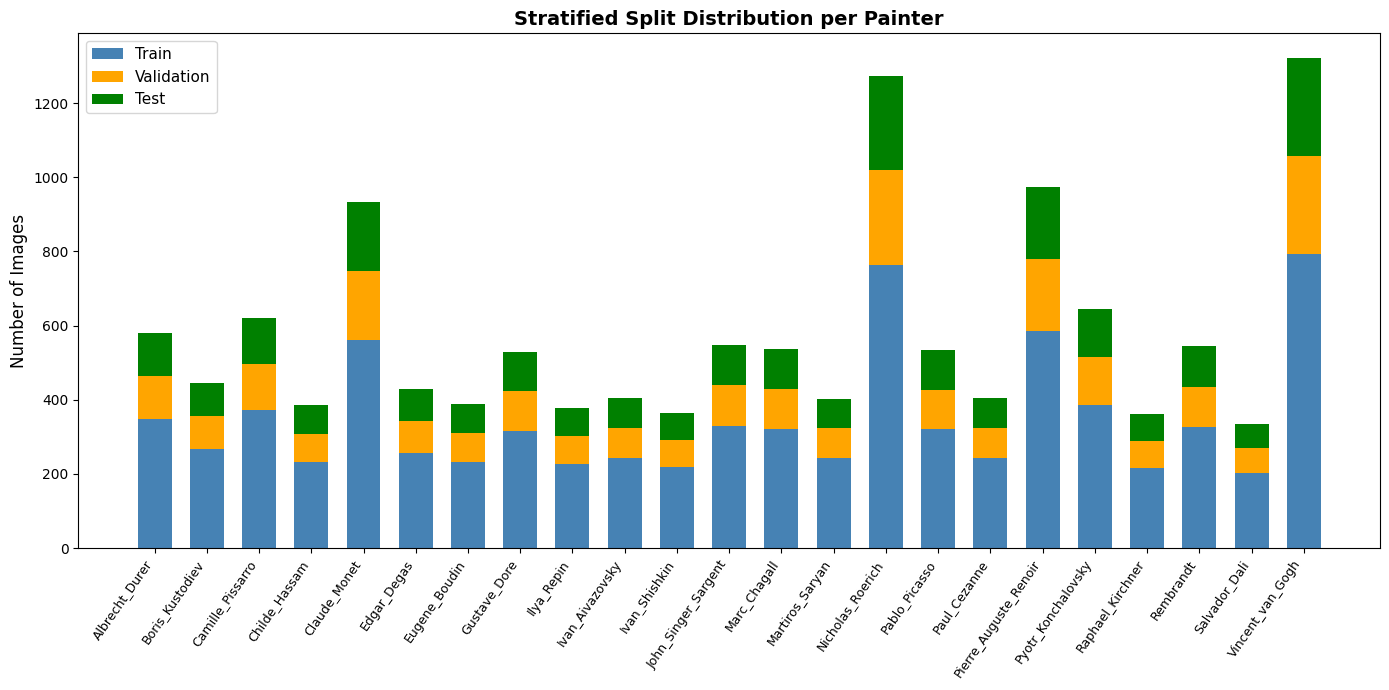

In [20]:
# Visualize split distribution per painter
painters = sorted(painter_split_counts.keys())
train_counts = [painter_split_counts[p]['train'] for p in painters]
val_counts = [painter_split_counts[p]['val'] for p in painters]
test_counts = [painter_split_counts[p]['test'] for p in painters]

x = np.arange(len(painters))
width = 0.65

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x, train_counts, width, label='Train', color='steelblue')
ax.bar(x, val_counts, width, bottom=train_counts, label='Validation', color='orange')
ax.bar(x, test_counts, width, bottom=[t+v for t,v in zip(train_counts, val_counts)], label='Test', color='green')

ax.set_xticks(x)
ax.set_xticklabels(painters, rotation=55, ha='right', fontsize=9)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Stratified Split Distribution per Painter', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 3.4. Random Sample of 20 Training Images
Following the Professor's recommendation, we sample 20 images from the training set to visually inspect the data our models will learn from and guide our modelling strategy.

In [21]:
# Sample 20 images from the training set only
train_data = [entry for entry in data if split_assignments[entry['filepath']] == 'train']

random.seed(SEED)
sample = random.sample(train_data, min(20, len(train_data)))

cols = 5
rows = 4
fig, axes = plt.subplots(rows, cols, figsize=(18, 16))
fig.suptitle(f'Random Sample of 20 Training Images (seed={SEED})', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(sample):
        entry = sample[idx]
        try:
            img = Image.open(entry['filepath'])
            ax.imshow(img)
            ax.set_title(f"{entry['painter']}\n{entry['width']}x{entry['height']}", fontsize=8)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nSample details (from training set, {len(train_data)} images):")
for i, entry in enumerate(sample, 1):
    print(f"  [{i:2d}] {entry['painter']:25s} | {entry['width']}x{entry['height']} | "
          f"{entry['filesize_kb']:.1f} KB | {entry['filename']}")

Output hidden; open in https://colab.research.google.com to view.

### 3.5. Create Directory Structure for Keras

In [22]:
# Build DataFrame with relative paths
rows = []
for entry in data:
    filepath = entry['filepath']
    painter = entry['painter']
    filename = entry['filename']
    relative_path = f"{painter}/{filename}"
    split = split_assignments[filepath]
    rows.append({
        'relative_path': relative_path,
        'painter': painter,
        'split': split,
    })

df_split = pd.DataFrame(rows)

In [23]:
# Create Keras-compatible directory structure
# When runned locally
split_dir = Path(os.path.join(".", 'wikiart_split'))

# When runned in Colab
# split_dir = Path('/content/drive/MyDrive/Data Science/2nd Semester/Deep_Learning/Project/wikiart_split')

print("Creating directory structure...")
for _, row in df_split.iterrows():
    src = dataset_path / row.relative_path
    dst = split_dir / row.split / row.painter / Path(row.relative_path).name
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

for split_name in ['train', 'val', 'test']:
    split_path = split_dir / split_name
    n_painters = len(list(split_path.iterdir()))
    n_images = sum(len(list(p.iterdir())) for p in split_path.iterdir())
    print(f"  {split_name:5s}: {n_painters} painters, {n_images} images")

Creating directory structure...
  train: 23 painters, 8002 images
  val  : 23 painters, 2670 images
  test : 23 painters, 2668 images
